In [ ]:
import pandas as pd

In [ ]:
year_by_df_ott_genre=pd.read_csv('2021-2025_total_ott_genre.csv', encoding='cp949')
year_by_df_ott_genre

,구분별(1),구분별(2),시점,응답자수 (명),영화 (%),예능/오락(개인방송 콘텐츠 포함) (%),드라마 (%),교양/다큐멘터리 (%),교육/학습 (%),애니메이션(만화) (%),스포츠 (%),뉴스 (%),공연(콘서트 연극 뮤지컬 등) (%),기타 (%)
0,전체,소계,2021,8293.7,9.0,44.5,20.6,3.8,2.4,3.1,6.7,8.7,-,1.1
1,성별,남,2021,4283.5,11.2,44.6,10.8,3.9,2.2,2.9,12.1,11.4,-,1.0
2,성별,여,2021,4010.2,6.7,44.5,31.1,3.7,2.6,3.3,1.0,5.8,-,1.2
3,연령,만10대미만,2021,174.5,0.4,40.8,0.4,0.6,8.7,47.8,0.3,0.9,-,0.0
4,연령,만10-19세,2021,880.1,4.0,59.1,7.7,3.3,9.5,13.2,2.0,0.6,-,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420,가구주와의관계,부모(배우자부모포함),2025,56.8,0.3,67.6,17.4,0.7,0.0,0.0,13.0,1.0,0.0,0.0
421,가구주와의관계,조부모(배우자조부모포함),2025,1.3,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
422,가구주와의관계,형제자매/그배우자,2025,85.4,0.9,75.0,21.9,0.0,0.8,1.3,0.0,0.0,0.0,0.0
423,가구주와의관계,기타친인척,2025,15.1,0.0,97.3,2.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0


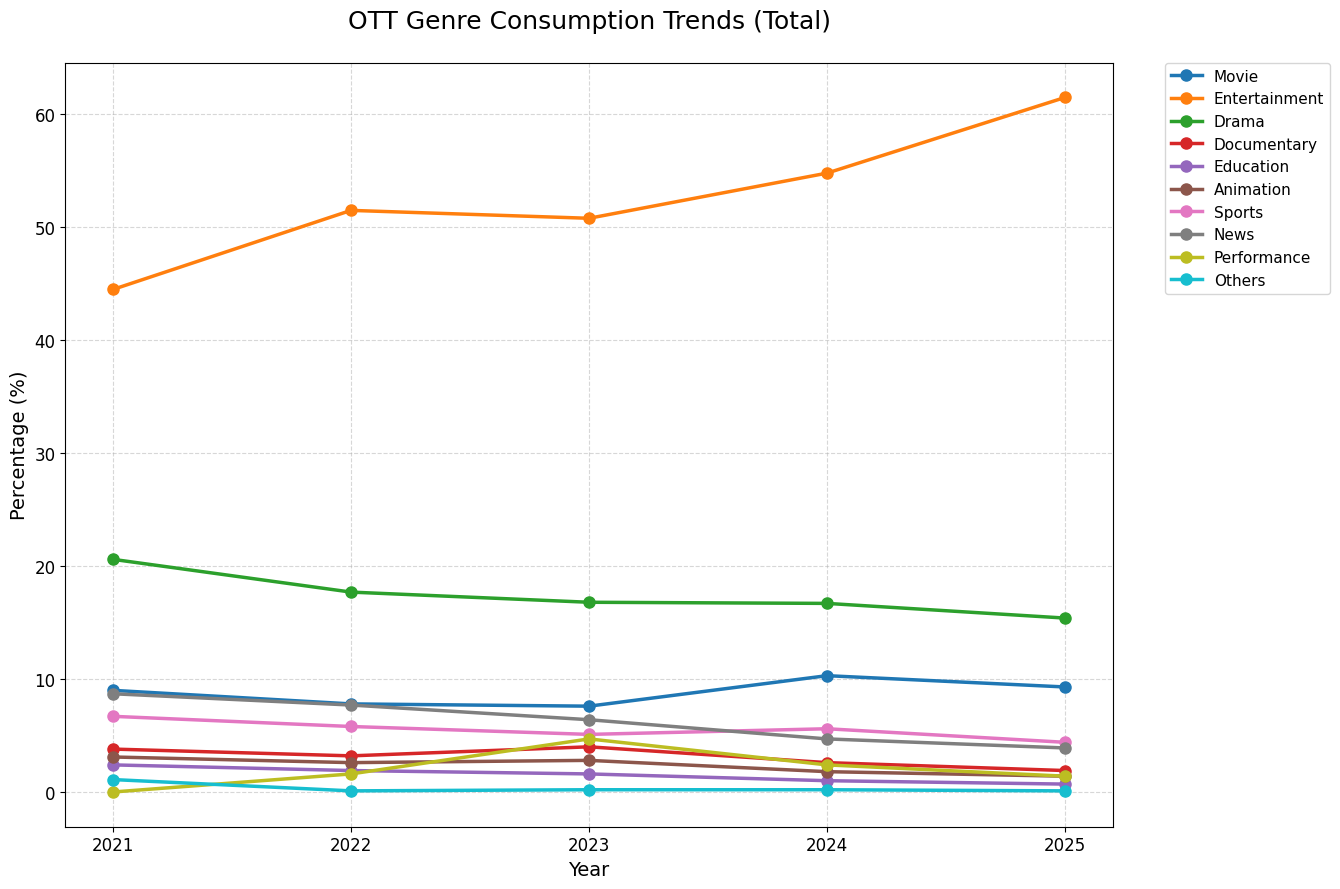

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reset font settings to default to avoid font errors
plt.rcParams.update(plt.rcParamsDefault)

# Mapping Korean genre columns to English labels
genre_map = {
    '영화 (%)': 'Movie',
    '예능/오락(개인방송 콘텐츠 포함) (%)': 'Entertainment',
    '드라마 (%)': 'Drama',
    '교양/다큐멘터리 (%)': 'Documentary',
    '교육/학습 (%)': 'Education',
    '애니메이션(만화) (%)': 'Animation',
    '스포츠 (%)': 'Sports',
    '뉴스 (%)': 'News',
    '공연(콘서트 연극 뮤지컬 등) (%)': 'Performance',
    '기타 (%)': 'Others'
}

# Filter data for the 'Total' (전체) and 'Subtotal' (소계) across all available years
trend_data = year_by_df_ott_genre[
    (year_by_df_ott_genre['구분별(1)'] == '전체') &
    (year_by_df_ott_genre['구분별(2)'] == '소계')
].copy()

# Clean and convert numeric columns
for kor_col, eng_col in genre_map.items():
    trend_data[eng_col] = pd.to_numeric(trend_data[kor_col].replace('-', '0'), errors='coerce').fillna(0)

# Sort by year (시점)
trend_data = trend_data.sort_values('시점')

# Plotting - Increased figsize and markers for better readability
plt.figure(figsize=(16, 9))
for eng_col in genre_map.values():
    plt.plot(trend_data['시점'], trend_data[eng_col], marker='o', markersize=8, linewidth=2.5, label=eng_col)

plt.title('OTT Genre Consumption Trends (Total)', fontsize=18, pad=25)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Percentage (%)', fontsize=14)

# Move legend further away and adjust layout
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=11)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(trend_data['시점'].unique(), fontsize=12)
plt.yticks(fontsize=12)

# Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

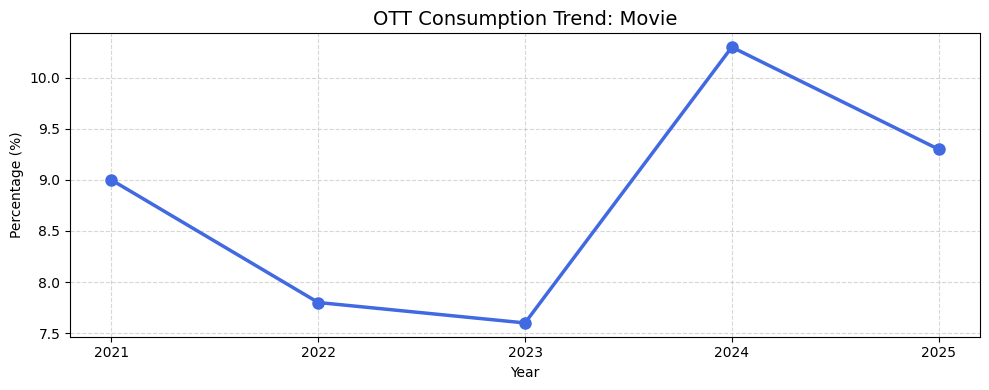

In [ ]:
# Common Setup for individual plots
import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)

genres_to_plot = [
    ('Movie', 'royalblue'),
    ('Entertainment', 'orange'),
    ('Drama', 'green'),
    ('Documentary', 'red'),
    ('Education', 'purple'),
    ('Animation', 'brown'),
    ('Sports', 'pink'),
    ('News', 'gray'),
    ('Performance', 'olive'),
    ('Others', 'cyan')
]

def plot_genre_trend(genre_name, color):
    plt.figure(figsize=(10, 4))
    plt.plot(trend_data['시점'], trend_data[genre_name], marker='o', markersize=8, linewidth=2.5, color=color)
    plt.title(f'OTT Consumption Trend: {genre_name}', fontsize=14)
    plt.xlabel('Year', fontsize=10)
    plt.ylabel('Percentage (%)', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(trend_data['시점'].unique())
    plt.tight_layout()
    plt.show()

# Plot the first genre
plot_genre_trend(genres_to_plot[0][0], genres_to_plot[0][1])

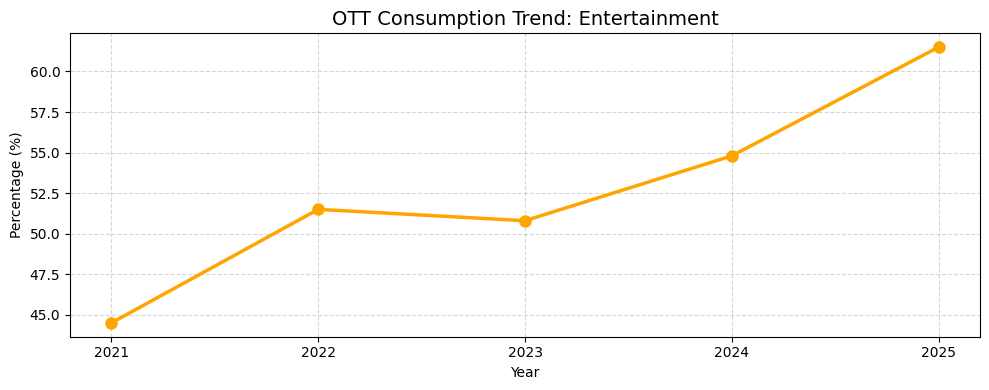

In [ ]:
# Plot for Entertainment
plot_genre_trend(genres_to_plot[1][0], genres_to_plot[1][1])

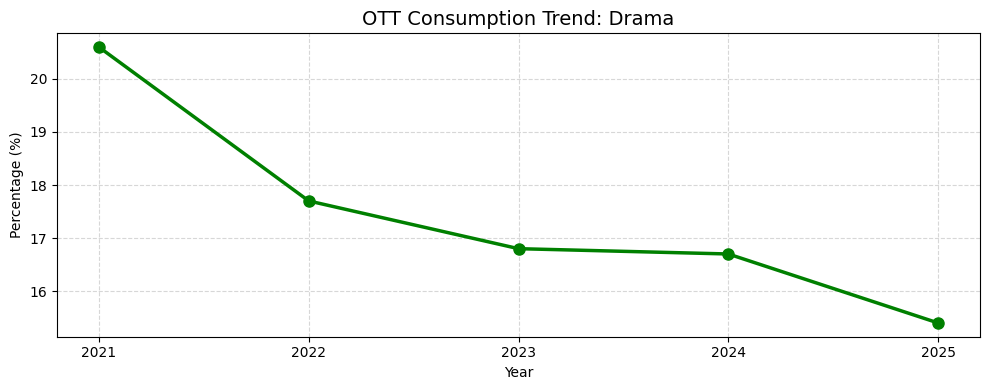

In [ ]:
# Plot for Drama
plot_genre_trend(genres_to_plot[2][0], genres_to_plot[2][1])

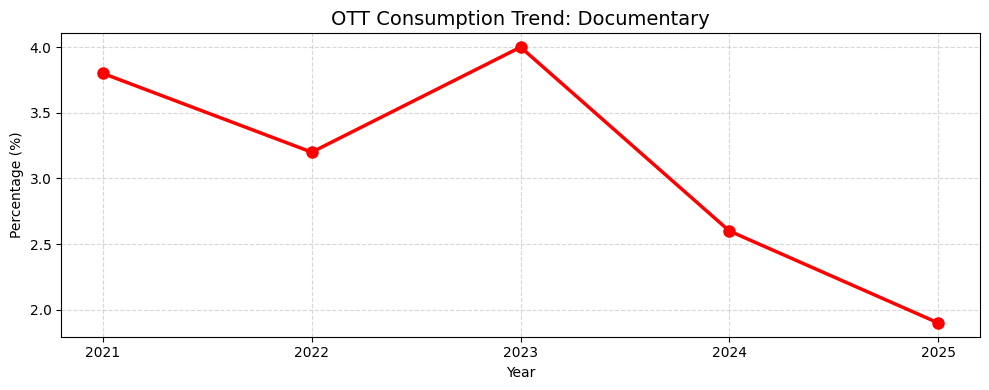

In [ ]:
# Plot for Documentary
plot_genre_trend(genres_to_plot[3][0], genres_to_plot[3][1])

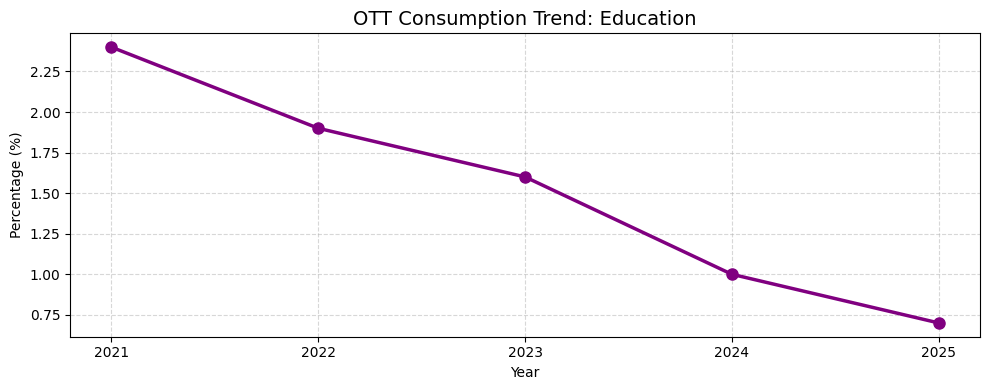

In [ ]:
# Plot for Education
plot_genre_trend(genres_to_plot[4][0], genres_to_plot[4][1])

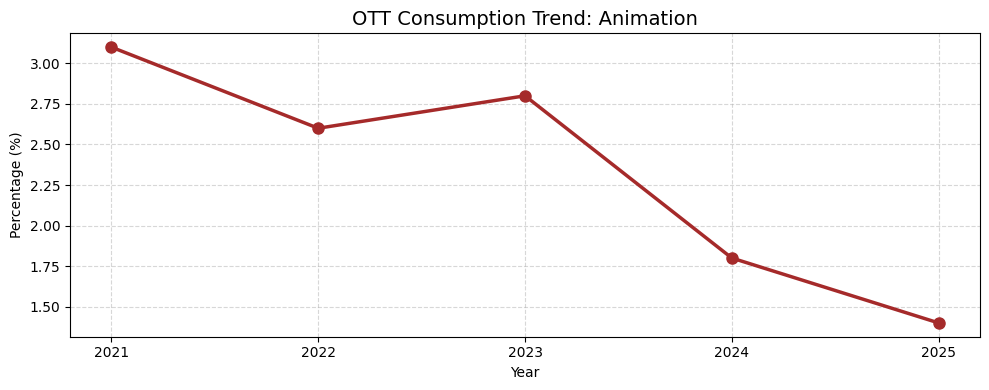

In [ ]:
# Plot for Animation
plot_genre_trend(genres_to_plot[5][0], genres_to_plot[5][1])

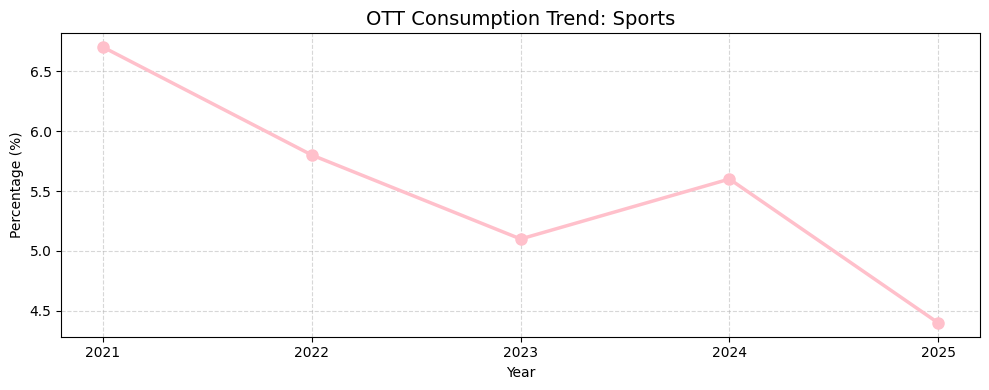

In [ ]:
# Plot for Sports
plot_genre_trend(genres_to_plot[6][0], genres_to_plot[6][1])

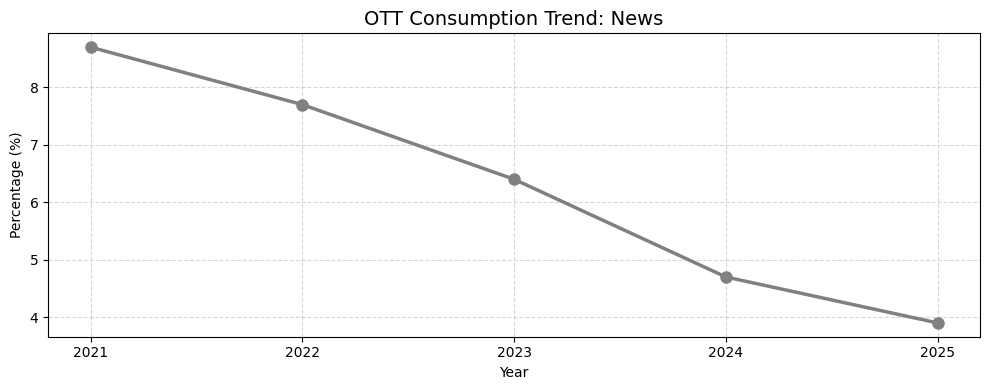

In [ ]:
# Plot for News
plot_genre_trend(genres_to_plot[7][0], genres_to_plot[7][1])

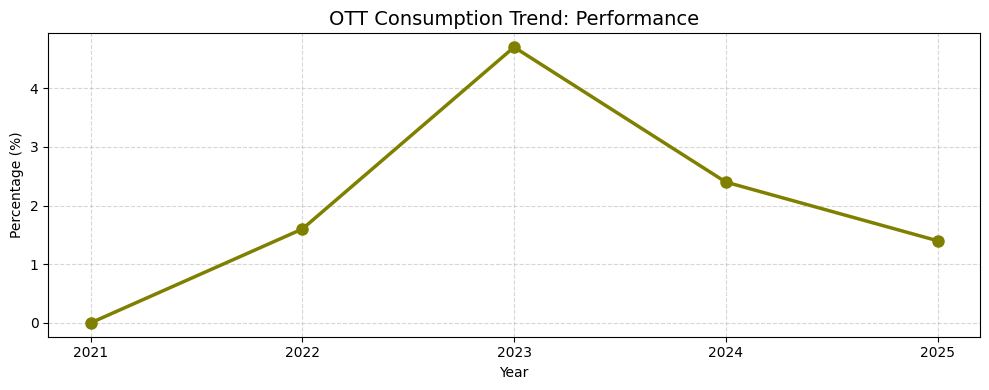

In [ ]:
# Plot for Performance
plot_genre_trend(genres_to_plot[8][0], genres_to_plot[8][1])

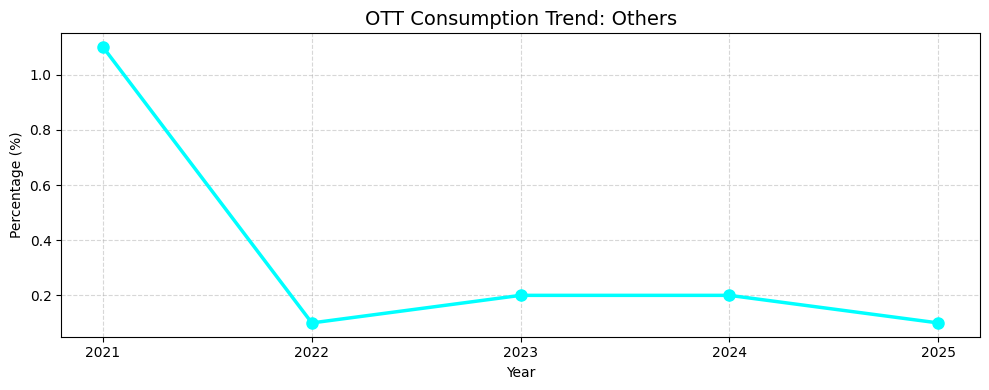

In [ ]:
# Plot for Others
plot_genre_trend(genres_to_plot[9][0], genres_to_plot[9][1])

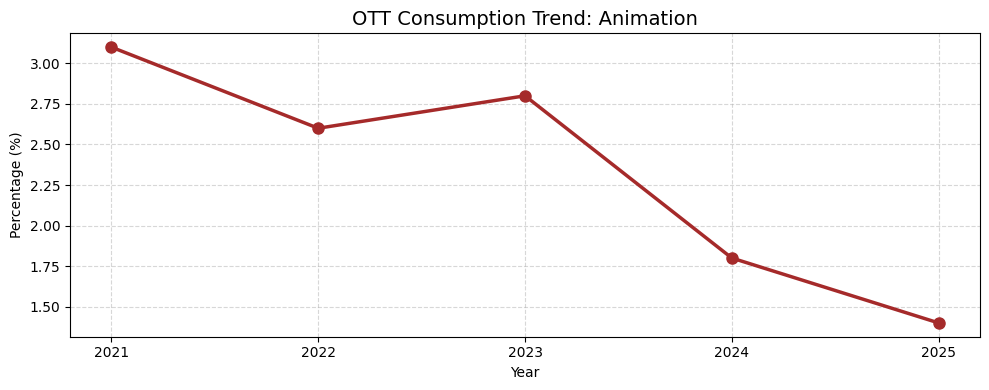

In [ ]:
# Plot for Animation
plot_genre_trend(genres_to_plot[5][0], genres_to_plot[5][1])

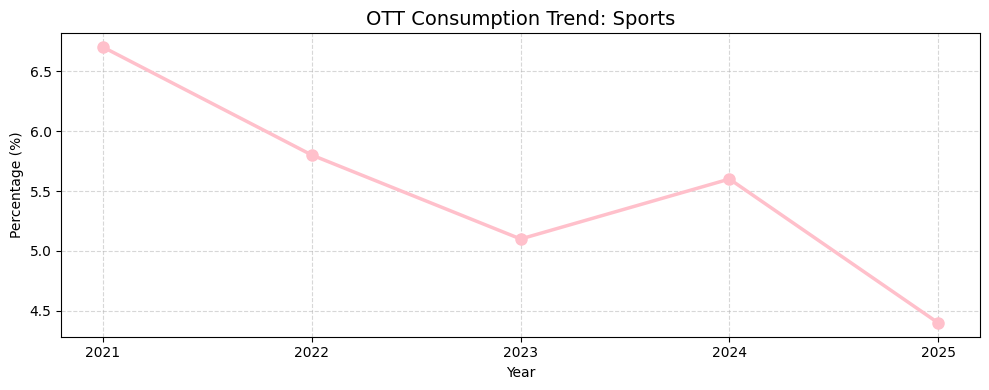

In [ ]:
# Plot for Sports
plot_genre_trend(genres_to_plot[6][0], genres_to_plot[6][1])

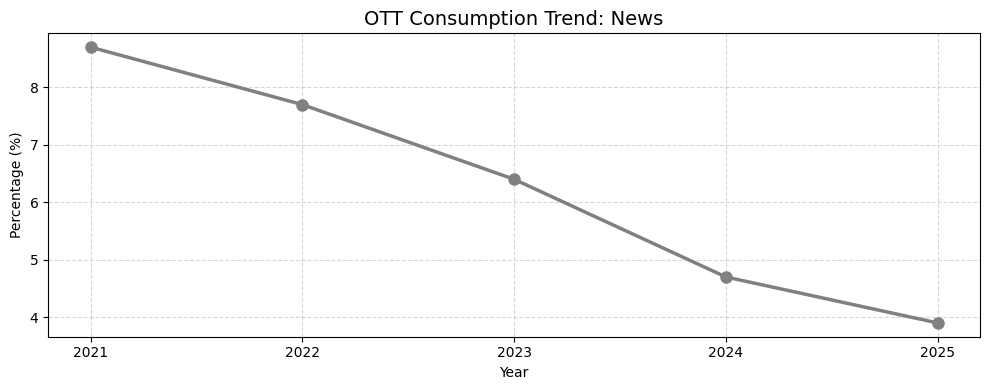

In [ ]:
# Plot for News
plot_genre_trend(genres_to_plot[7][0], genres_to_plot[7][1])

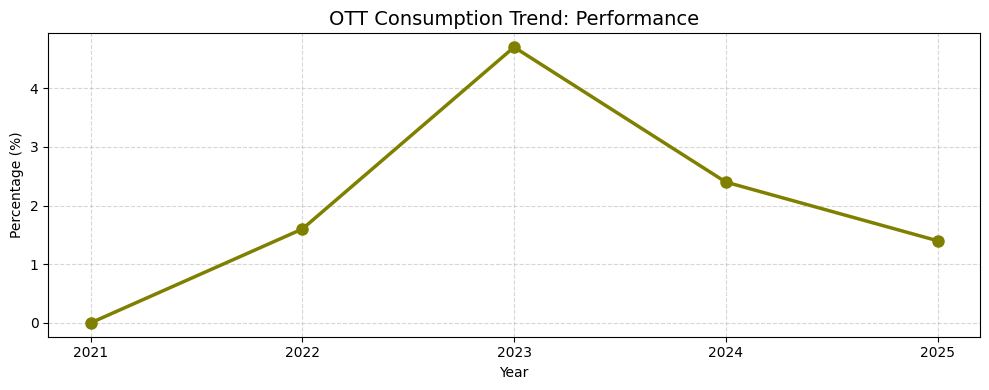

In [ ]:
# Plot for Performance
plot_genre_trend(genres_to_plot[8][0], genres_to_plot[8][1])

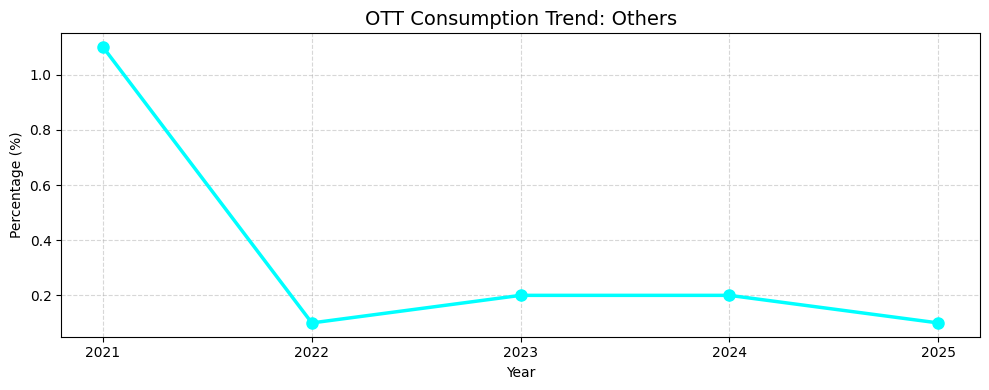

In [ ]:
# Plot for Others
plot_genre_trend(genres_to_plot[9][0], genres_to_plot[9][1])

In [ ]:
# Check the processed trend_data and original columns to verify values
print("--- Processed Trend Data (English Labels) ---")
display(trend_data[['시점'] + list(genre_map.values())])

print("\n--- Original Source Data (Korean Labels) ---")
display(year_by_df_ott_genre[(year_by_df_ott_genre['구분별(1)'] == '전체') & (year_by_df_ott_genre['구분별(2)'] == '소계')][['시점'] + list(genre_map.keys())])

--- Processed Trend Data (English Labels) ---


,시점,Movie,Entertainment,Drama,Documentary,Education,Animation,Sports,News,Performance,Others
0,2021,9.0,44.5,20.6,3.8,2.4,3.1,6.7,8.7,0.0,1.1
85,2022,7.8,51.5,17.7,3.2,1.9,2.6,5.8,7.7,1.6,0.1
170,2023,7.6,50.8,16.8,4.0,1.6,2.8,5.1,6.4,4.7,0.2
254,2024,10.3,54.8,16.7,2.6,1.0,1.8,5.6,4.7,2.4,0.2
339,2025,9.3,61.5,15.4,1.9,0.7,1.4,4.4,3.9,1.4,0.1



--- Original Source Data (Korean Labels) ---


,시점,영화 (%),예능/오락(개인방송 콘텐츠 포함) (%),드라마 (%),교양/다큐멘터리 (%),교육/학습 (%),애니메이션(만화) (%),스포츠 (%),뉴스 (%),공연(콘서트 연극 뮤지컬 등) (%),기타 (%)
0,2021,9.0,44.5,20.6,3.8,2.4,3.1,6.7,8.7,-,1.1
85,2022,7.8,51.5,17.7,3.2,1.9,2.6,5.8,7.7,1.6,0.1
170,2023,7.6,50.8,16.8,4.0,1.6,2.8,5.1,6.4,4.7,0.2
254,2024,10.3,54.8,16.7,2.6,1.0,1.8,5.6,4.7,2.4,0.2
339,2025,9.3,61.5,15.4,1.9,0.7,1.4,4.4,3.9,1.4,0.1


In [ ]:
import pandas as pd

# 각 연도별 장르 수치 합계 계산
genre_cols_eng = list(genre_map.values())
trend_data['Total_Sum'] = trend_data[genre_cols_eng].sum(axis=1)

print("--- 연도별 장르 수치 합계 및 상세 데이터 ---")
display_cols = ['시점'] + genre_cols_eng + ['Total_Sum']
display(trend_data[display_cols])

print("\n[분석 결과]")
for index, row in trend_data.iterrows():
    print(f"{int(row['시점'])}년 총합: {row['Total_Sum']:.1f}%")

--- 연도별 장르 수치 합계 및 상세 데이터 ---


,시점,Movie,Entertainment,Drama,Documentary,Education,Animation,Sports,News,Performance,Others,Total_Sum
0,2021,9.0,44.5,20.6,3.8,2.4,3.1,6.7,8.7,0.0,1.1,99.9
85,2022,7.8,51.5,17.7,3.2,1.9,2.6,5.8,7.7,1.6,0.1,99.9
170,2023,7.6,50.8,16.8,4.0,1.6,2.8,5.1,6.4,4.7,0.2,100.0
254,2024,10.3,54.8,16.7,2.6,1.0,1.8,5.6,4.7,2.4,0.2,100.1
339,2025,9.3,61.5,15.4,1.9,0.7,1.4,4.4,3.9,1.4,0.1,100.0



[분석 결과]
2021년 총합: 99.9%
2022년 총합: 99.9%
2023년 총합: 100.0%
2024년 총합: 100.1%
2025년 총합: 100.0%
